## 1. Setup và Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("✓ Imports successful!")

✓ Imports successful!


## 2. Load Data

In [7]:
# Load all three files

nodes = pd.read_csv('../data/raw/nodes.csv')
edges = pd.read_csv('../data/raw/edges.csv')
components = pd.read_csv('../data/raw/connected_components.csv')

print(f"\n✓ Nodes: {nodes.shape}")
print(f"✓ Edges: {edges.shape}")
print(f"✓ Components: {components.shape}")



✓ Nodes: (444521, 2)
✓ Edges: (367137, 3)
✓ Components: (121810, 2)


## 3. Basic Data Information

In [11]:
# Nodes info
print(f"Shape: {nodes.shape}")

print(f"\nColumns: {list(nodes.columns)}")

print(f"\nData types:\n{nodes.dtypes}")

print(f"\nMissing values:\n{nodes.isnull().sum()}")

print(f"\nUnique values:")
print(f"  - clId: {nodes['clId'].nunique()}")
print(f"  - ccId: {nodes['ccId'].nunique()}")

nodes.head(10)

Shape: (444521, 2)

Columns: ['clId', 'ccId']

Data types:
clId    int64
ccId    int64
dtype: object

Missing values:
clId    0
ccId    0
dtype: int64

Unique values:
  - clId: 444521
  - ccId: 121810


,clId,ccId
0,515498410,41121
1,630366534,27974
2,903790945,108020
3,449108887,6544
4,877994419,27234
5,283837110,18144
6,461520122,88159
7,151399292,5421
8,637827446,10948
9,153446307,1752


In [12]:
# Edges info
print(f"Shape: {edges.shape}")

print(f"\nColumns: {list(edges.columns)}")

print(f"\nData types:\n{edges.dtypes}")

print(f"\nMissing values:\n{edges.isnull().sum()}")

print(f"\nUnique values:")
print(f"  - clId1: {edges['clId1'].nunique()}")
print(f"  - clId2: {edges['clId2'].nunique()}")
print(f"  - txId: {edges['txId'].nunique()}")

edges.head(10)

Shape: (367137, 3)

Columns: ['clId1', 'clId2', 'txId']

Data types:
clId1    int64
clId2    int64
txId     int64
dtype: object

Missing values:
clId1    0
clId2    0
txId     0
dtype: int64

Unique values:
  - clId1: 301947
  - clId2: 314882
  - txId: 341991


,clId1,clId2,txId
0,753456251,753456254,29911377
1,756183927,759736869,51855
2,623574254,622935561,27784128
3,751464959,751464964,76668
4,751464834,751464959,2592471
5,751356702,45249443,77350
6,606080117,725900996,91103
7,748214109,759726459,97938
8,919309127,953058302,109765
9,18356958,738291653,119202


In [13]:
# Components info
print(f"Shape: {components.shape}")

print(f"\nColumns: {list(components.columns)}")

print(f"\nData types:\n{components.dtypes}")

print(f"\nMissing values:\n{components.isnull().sum()}")

print(f"\nLabel distribution:\n{components['ccLabel'].value_counts()}")

components.head(10)

Shape: (121810, 2)

Columns: ['ccId', 'ccLabel']

Data types:
ccId        int64
ccLabel    object
dtype: object

Missing values:
ccId       0
ccLabel    0
dtype: int64

Label distribution:
ccLabel
licit         119047
suspicious      2763
Name: count, dtype: int64


,ccId,ccLabel
0,0,licit
1,1,licit
2,2,licit
3,3,licit
4,4,licit
5,5,licit
6,6,licit
7,7,licit
8,8,licit
9,9,licit


## 4. Merge Data

In [15]:
# Merge nodes với components để có labels
nodes_labeled = nodes.merge(components, on='ccId', how='left')

# Convert to binary labels
nodes_labeled['label'] = (nodes_labeled['ccLabel'] == 'suspicious').astype(int)

print("Merged dataset:")
print(f"Shape: {nodes_labeled.shape}")
print(f"\nColumns: {list(nodes_labeled.columns)}")
print(f"\nMissing after merge:\n{nodes_labeled.isnull().sum()}")

nodes_labeled.head()

Merged dataset:
Shape: (444521, 4)

Columns: ['clId', 'ccId', 'ccLabel', 'label']

Missing after merge:
clId       0
ccId       0
ccLabel    0
label      0
dtype: int64


,clId,ccId,ccLabel,label
0,515498410,41121,licit,0
1,630366534,27974,licit,0
2,903790945,108020,licit,0
3,449108887,6544,suspicious,1
4,877994419,27234,licit,0


## 5. Class Distribution Analysis

In [17]:
# Class distribution
label_counts = nodes_labeled['label'].value_counts().sort_index()
label_names = {0: 'Licit', 1: 'Suspicious'}

print(f"\nLabel counts:")
for label, count in label_counts.items():
    name = label_names[label]
    pct = count / len(nodes_labeled) * 100
    print(f"\t{name:12s}: {count:>8,} ({pct:>6.2f}%)")

print(f"\nClass imbalance ratio: {label_counts[0] / label_counts[1]:.2f} : 1")


Label counts:
	Licit       :  434,055 ( 97.65%)
	Suspicious  :   10,466 (  2.35%)

Class imbalance ratio: 41.47 : 1


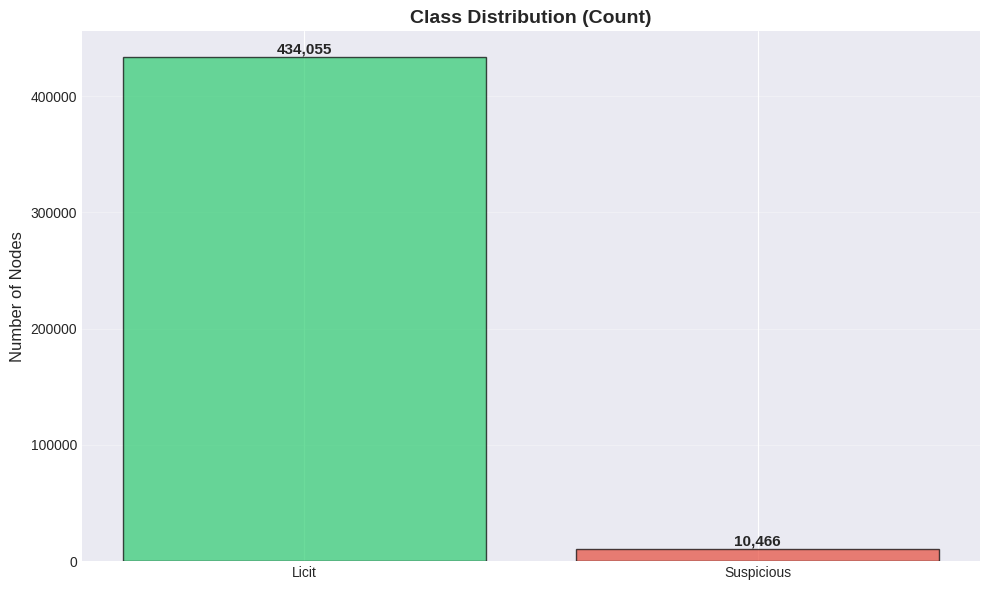

In [22]:
# Visualize class distribution
fig, ax = plt.subplots(figsize=(10, 6))

# Bar plot
colors = ['#2ecc71', '#e74c3c']  # Green for licit, Red for suspicious
bars = ax.bar(['Licit', 'Suspicious'], label_counts.values, color=colors, alpha=0.7, edgecolor='black')
ax.set_ylabel('Number of Nodes', fontsize=12)
ax.set_title('Class Distribution (Count)', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

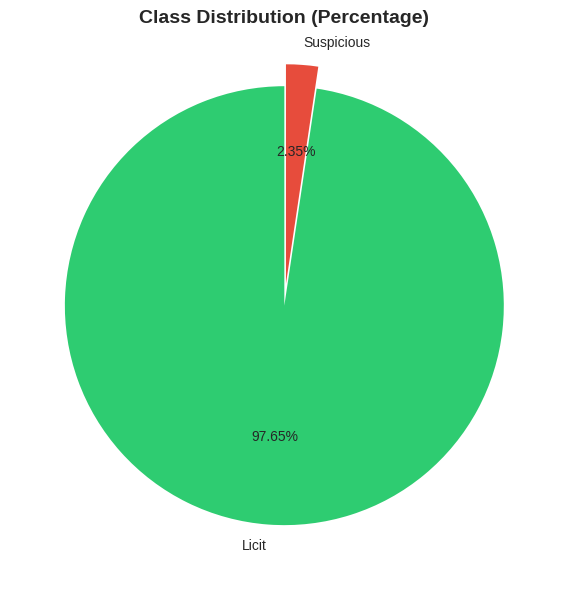

In [23]:
# Pie chart
fig, ax = plt.subplots(figsize=(6, 6))
# Ensure colors defined locally
colors = ['#2ecc71', '#e74c3c']  # Green for licit, Red for suspicious
ax.pie(label_counts.values, labels=['Licit', 'Suspicious'], autopct='%1.2f%%',
       colors=colors, startangle=90, explode=(0, 0.1))
ax.set_title('Class Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Connected Components Analysis

In [24]:
# Component sizes
component_sizes = nodes_labeled['ccId'].value_counts()

print(f"\nTotal components: {len(component_sizes)}")
print(f"\nComponent size statistics:")
print(component_sizes.describe())

print(f"\nLargest 20 components:")
print(component_sizes.head(20))


Total components: 121810

Component size statistics:
count    121810.000000
mean          3.649298
std           3.240420
min           2.000000
25%           2.000000
50%           3.000000
75%           4.000000
max         296.000000
Name: count, dtype: float64

Largest 20 components:
ccId
0     296
1     282
2     148
3     123
4     110
5      98
6      92
8      91
7      91
9      90
10     87
11     86
12     82
13     79
14     77
15     76
16     70
17     70
18     69
21     64
Name: count, dtype: int64


In [25]:
# Analyze components by label
component_analysis = nodes_labeled.groupby('ccId').agg({
    'clId': 'count',
    'label': 'mean'
}).rename(columns={'clId': 'size', 'label': 'suspicious_ratio'})

component_analysis['has_suspicious'] = (component_analysis['suspicious_ratio'] > 0).astype(int)

print("Components with suspicious activity:")
suspicious_components = component_analysis[component_analysis['has_suspicious'] == 1]
print(f"  Total: {len(suspicious_components)} / {len(component_analysis)} ({len(suspicious_components)/len(component_analysis)*100:.2f}%)")

print(f"\nSize statistics:")
print(suspicious_components['size'].describe())

Components with suspicious activity:
  Total: 2763 / 121810 (2.27%)

Size statistics:
count    2763.000000
mean        3.787912
std         2.580753
min         2.000000
25%         2.000000
50%         3.000000
75%         5.000000
max        30.000000
Name: size, dtype: float64


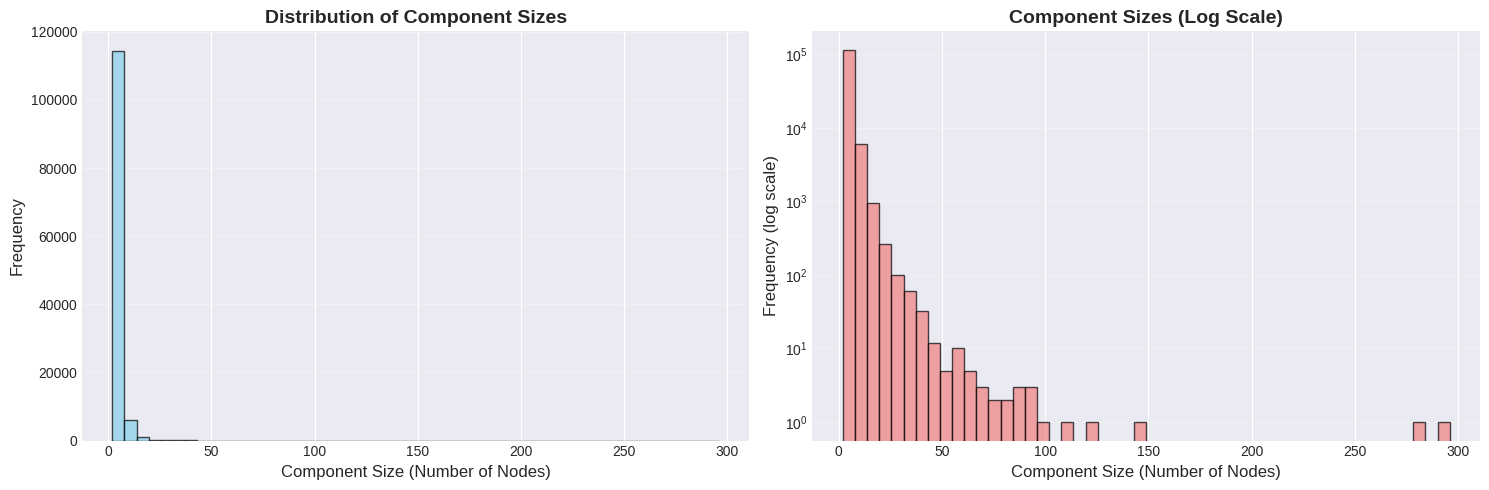

In [26]:
# Visualize component size distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Histogram of component sizes
ax1.hist(component_sizes.values, bins=50, edgecolor='black', alpha=0.7, color='skyblue')
ax1.set_xlabel('Component Size (Number of Nodes)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Distribution of Component Sizes', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Log scale for better view
ax2.hist(component_sizes.values, bins=50, edgecolor='black', alpha=0.7, color='lightcoral')
ax2.set_xlabel('Component Size (Number of Nodes)', fontsize=12)
ax2.set_ylabel('Frequency (log scale)', fontsize=12)
ax2.set_yscale('log')
ax2.set_title('Component Sizes (Log Scale)', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Graph Structure Analysis

In [28]:
# Basic graph statistics
num_nodes = len(nodes)
num_edges = len(edges)
num_unique_nodes_in_edges = len(set(edges['clId1'].unique()) | set(edges['clId2'].unique()))

print(f"\nNodes:")
print(f"\tTotal in nodes.csv: {num_nodes:,}")
print(f"\tAppearing in edges: {num_unique_nodes_in_edges:,}")
print(f"\tIsolated nodes: {num_nodes - num_unique_nodes_in_edges:,}")

print(f"\nEdges:")
print(f"\tTotal edges: {num_edges:,}")
print(f"\tUnique edges: {edges[['clId1', 'clId2']].drop_duplicates().shape[0]:,}")

# Density
max_possible_edges = num_unique_nodes_in_edges * (num_unique_nodes_in_edges - 1)
density = num_edges / max_possible_edges if max_possible_edges > 0 else 0
print(f"\nGraph Density: {density:.6f}")


Nodes:
	Total in nodes.csv: 444,521
	Appearing in edges: 444,521
	Isolated nodes: 0

Edges:
	Total edges: 367,137
	Unique edges: 343,192

Graph Density: 0.000002


In [29]:
# Degree analysis
out_degrees = edges['clId1'].value_counts()
in_degrees = edges['clId2'].value_counts()

# All nodes degrees (0 if not in edges)
all_nodes_set = set(nodes['clId'])
out_degree_dict = {node: out_degrees.get(node, 0) for node in all_nodes_set}
in_degree_dict = {node: in_degrees.get(node, 0) for node in all_nodes_set}
total_degree_dict = {node: out_degree_dict[node] + in_degree_dict[node] for node in all_nodes_set}

# Convert to series
out_degree_series = pd.Series(out_degree_dict)
in_degree_series = pd.Series(in_degree_dict)
total_degree_series = pd.Series(total_degree_dict)

print(f"\nOut-degree:")
print(out_degree_series.describe())

print(f"\nIn-degree:")
print(in_degree_series.describe())

print(f"\nTotal degree:")
print(total_degree_series.describe())


Out-degree:
count    444521.000000
mean          0.825916
std           1.124055
min           0.000000
25%           0.000000
50%           1.000000
75%           1.000000
max         138.000000
dtype: float64

In-degree:
count    444521.000000
mean          0.825916
std           1.051104
min           0.000000
25%           0.000000
50%           1.000000
75%           1.000000
max         196.000000
dtype: float64

Total degree:
count    444521.000000
mean          1.651832
std           1.519417
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max         196.000000
dtype: float64


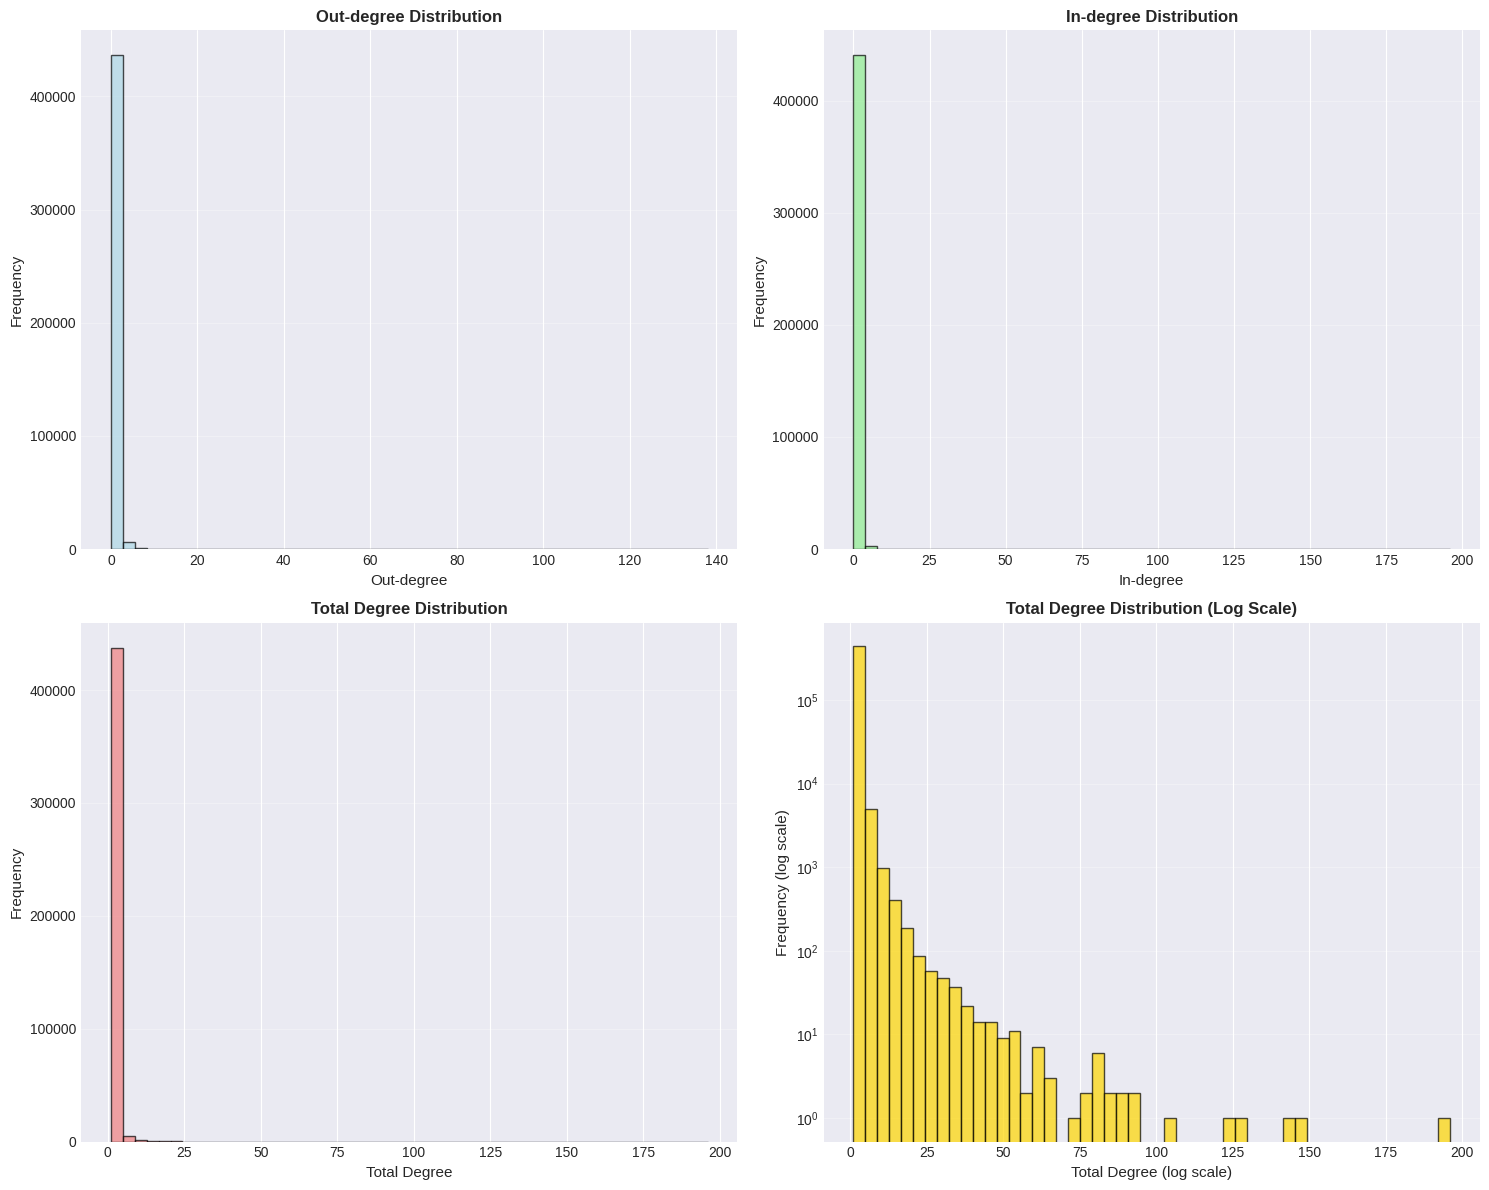

In [30]:
# Degree distribution visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Out-degree distribution
ax = axes[0, 0]
ax.hist(out_degree_series.values, bins=50, edgecolor='black', alpha=0.7, color='lightblue')
ax.set_xlabel('Out-degree', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Out-degree Distribution', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# In-degree distribution
ax = axes[0, 1]
ax.hist(in_degree_series.values, bins=50, edgecolor='black', alpha=0.7, color='lightgreen')
ax.set_xlabel('In-degree', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('In-degree Distribution', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Total degree distribution
ax = axes[1, 0]
ax.hist(total_degree_series.values, bins=50, edgecolor='black', alpha=0.7, color='lightcoral')
ax.set_xlabel('Total Degree', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Total Degree Distribution', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Log-scale total degree
ax = axes[1, 1]
ax.hist(total_degree_series[total_degree_series > 0].values, bins=50, 
        edgecolor='black', alpha=0.7, color='gold')
ax.set_xlabel('Total Degree (log scale)', fontsize=11)
ax.set_ylabel('Frequency (log scale)', fontsize=11)
ax.set_yscale('log')
ax.set_title('Total Degree Distribution (Log Scale)', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [31]:
# Nodes with highest degrees

top_total = total_degree_series.nlargest(10)
top_out = out_degree_series.nlargest(10)
top_in = in_degree_series.nlargest(10)

print("\nTop 10 by total degree:")
for node, degree in top_total.items():
    print(f"  Node {node}: {degree} (out: {out_degree_dict[node]}, in: {in_degree_dict[node]})")

print("\nTop 10 by out-degree:")
for node, degree in top_out.items():
    print(f"  Node {node}: {degree}")

print("\nTop 10 by in-degree:")
for node, degree in top_in.items():
    print(f"  Node {node}: {degree}")


Top 10 by total degree:
  Node 191543832: 196 (out: 0, in: 196)
  Node 455672577: 146 (out: 0, in: 146)
  Node 940707628: 145 (out: 138, in: 7)
  Node 41461859: 126 (out: 1, in: 125)
  Node 22413794: 125 (out: 125, in: 0)
  Node 82484742: 103 (out: 103, in: 0)
  Node 9570706: 92 (out: 92, in: 0)
  Node 7219677: 91 (out: 91, in: 0)
  Node 72401546: 89 (out: 9, in: 80)
  Node 632641790: 89 (out: 0, in: 89)

Top 10 by out-degree:
  Node 940707628: 138
  Node 22413794: 125
  Node 82484742: 103
  Node 9570706: 92
  Node 7219677: 91
  Node 161190725: 81
  Node 16215795: 80
  Node 22414024: 77
  Node 282443382: 76
  Node 119556035: 73

Top 10 by in-degree:
  Node 191543832: 196
  Node 455672577: 146
  Node 41461859: 125
  Node 632641790: 89
  Node 82484739: 85
  Node 886330110: 82
  Node 72401546: 80
  Node 16215785: 80
  Node 9257810: 63
  Node 512282433: 61


## 8. Temporal Analysis (txId)

In [32]:
# txId statistics
print(f"\nTotal unique txIds: {edges['txId'].nunique():,}")
print(f"Total edges: {len(edges):,}")
print(f"Multiple edges per txId: {len(edges) - edges['txId'].nunique():,}")

print(f"\ntxId range:")
print(f"\tMin: {edges['txId'].min():,}")
print(f"\tMax: {edges['txId'].max():,}")
print(f"\tSpan: {edges['txId'].max() - edges['txId'].min():,}")

# Check if txId is sequential
tx_ids_sorted = edges['txId'].sort_values().unique()
gaps = np.diff(tx_ids_sorted)
print(f"\ntxId gaps:")
print(f"\tMean gap: {gaps.mean():.2f}")
print(f"\tMedian gap: {np.median(gaps):.2f}")
print(f"\tMax gap: {gaps.max():,}")

# txId frequency
txid_counts = edges['txId'].value_counts()
print(f"\nTxId frequency distribution:")
print(txid_counts.describe())


Total unique txIds: 341,991
Total edges: 367,137
Multiple edges per txId: 25,146

txId range:
	Min: 43,705
	Max: 795,562,020
	Span: 795,518,315

txId gaps:
	Mean gap: 2326.14
	Median gap: 960.00
	Max gap: 202,037

TxId frequency distribution:
count    341991.000000
mean          1.073528
std           0.272780
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          20.000000
Name: count, dtype: float64


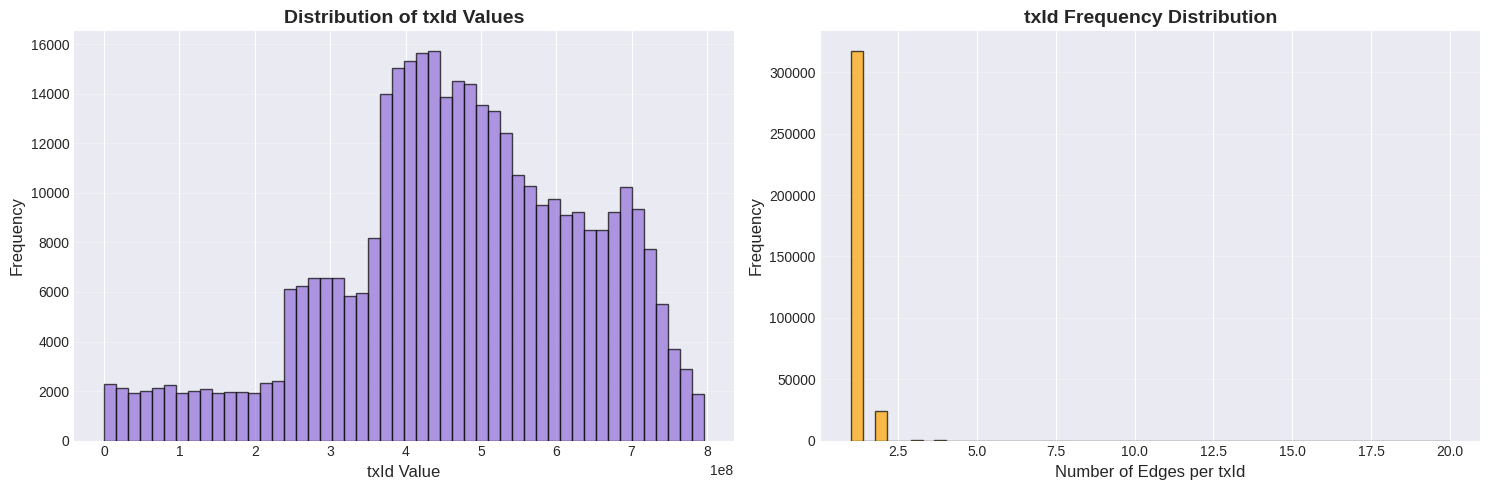

In [33]:
# Visualize txId distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# txId values distribution
ax1.hist(edges['txId'].values, bins=50, edgecolor='black', alpha=0.7, color='mediumpurple')
ax1.set_xlabel('txId Value', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Distribution of txId Values', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# txId frequency
ax2.hist(txid_counts.values, bins=50, edgecolor='black', alpha=0.7, color='orange')
ax2.set_xlabel('Number of Edges per txId', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('txId Frequency Distribution', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()